<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Line Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on using line charts to analyze trends over time and across different categories in a dataset.



## Objectives


In this lab you will perform the following:


- Track trends in compensation across age groups and specific age ranges.

- Analyze job satisfaction trends based on experience level.

- Explore and interpret line charts to identify patterns and trends.


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas
!pip install seaborn
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]


In [2]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



#### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv


--2026-09-18 10:59:25--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  36.3MB/s    in 4.8s    

2026-09-18 10:59:30 (32.0 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


#### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")


#### Display the first few rows to understand the structure of the data


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Trends in Compensation Over Age Groups


##### 1. Line Chart of Median `ConvertedCompYearly` by Age Group


- Track how the median yearly compensation (ConvertedCompYearly) changes across different age groups.

- Use a line chart to visualize these trends.


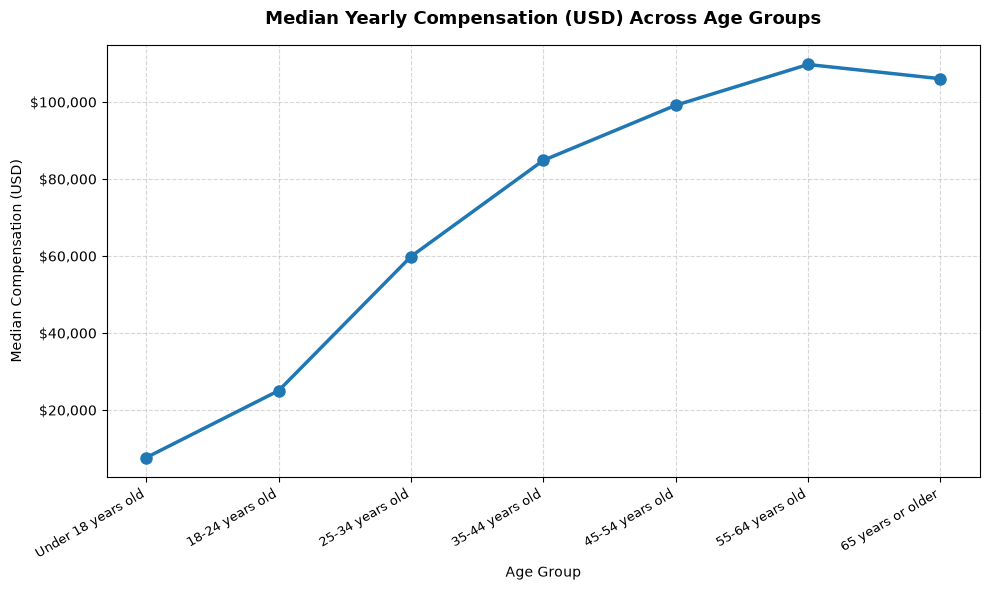

In [7]:
## Write your code here
# Select age and compensation columns
cols = ["Age", "ConvertedCompYearly"]
df_age_line = df[cols].dropna().copy()
df_age_line = df_age_line[df_age_line["Age"] != "Prefer not to say"].copy()

# Enforce strict chronological ordering
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
]

# Compute median yearly compensation per age group
median_comp_age = (
    df_age_line.groupby("Age")["ConvertedCompYearly"]
    .median()
    .reindex([a for a in age_order if a in df_age_line["Age"].values])
    .reset_index()
)

# Render Line Chart
plt.figure(figsize=(10, 6))

plt.plot(
    median_comp_age["Age"],
    median_comp_age["ConvertedCompYearly"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#1f77b4",
)

plt.title(
    "Median Yearly Compensation (USD) Across Age Groups",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Group", fontsize=10)
plt.ylabel("Median Compensation (USD)", fontsize=10)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)

# Format y-axis values as currency
plt.gca().yaxis.set_major_formatter("${x:,.0f}")

plt.tight_layout()
plt.show()

Median annual compensation ($USD$) exhibits a strong, steady upward trajectory as developer age increases, peaking during senior career stages (ages 45–64). A minor drop occurs in the 65+ age group, likely reflecting semi-retirement, transitions into part-time or advisory roles, or scaled-back working hours.

##### 2. Line Chart of Median `ConvertedCompYearly` for Ages 25 to 45


For a closer look, plot a line chart focusing on the median compensation for respondents between ages 25 and 45.


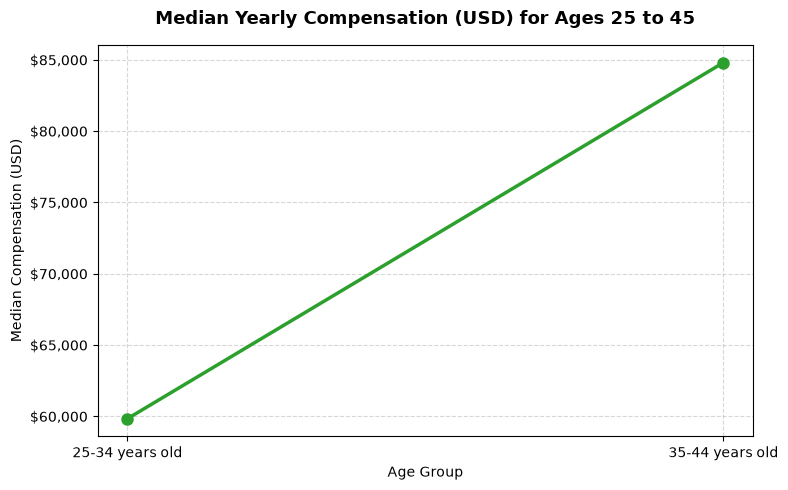

In [8]:
## Write your code here
# Select age and compensation columns
cols = ["Age", "ConvertedCompYearly"]
df_age_sub = df[cols].dropna().copy()

# Filter for age groups between 25 and 45 years old
filtered_age_order = ["25-34 years old", "35-44 years old"]

# Compute median yearly compensation for target age groups
median_comp_25_45 = (
    df_age_sub.groupby("Age")["ConvertedCompYearly"]
    .median()
    .reindex([a for a in filtered_age_order if a in df_age_sub["Age"].values])
    .reset_index()
)

# Render Line Chart
plt.figure(figsize=(8, 5))

plt.plot(
    median_comp_25_45["Age"],
    median_comp_25_45["ConvertedCompYearly"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#2ca02c",
)

plt.title(
    "Median Yearly Compensation (USD) for Ages 25 to 45",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Age Group", fontsize=10)
plt.ylabel("Median Compensation (USD)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

# Format y-axis values as currency
plt.gca().yaxis.set_major_formatter("${x:,.0f}")

plt.tight_layout()
plt.show()

Zooming in on the 25–45 age window reveals the steepest career earning acceleration. Median compensation increases substantially from `~$60,000` (25–34 age group) to `~$85,000` (35–44 age group)—a >40% jump (`$25K` increase) driven by transitions into senior engineering, architectural, and lead roles.

### Task 2: Trends in Job Satisfaction by Experience Level



##### 1. Line Chart of Job Satisfaction (`JobSatPoints_6`) by Experience Level



- Use a column that approximates experience level to analyze how job satisfaction changes with experience.

- If needed, substitute an available experience-related column for `Experience`.


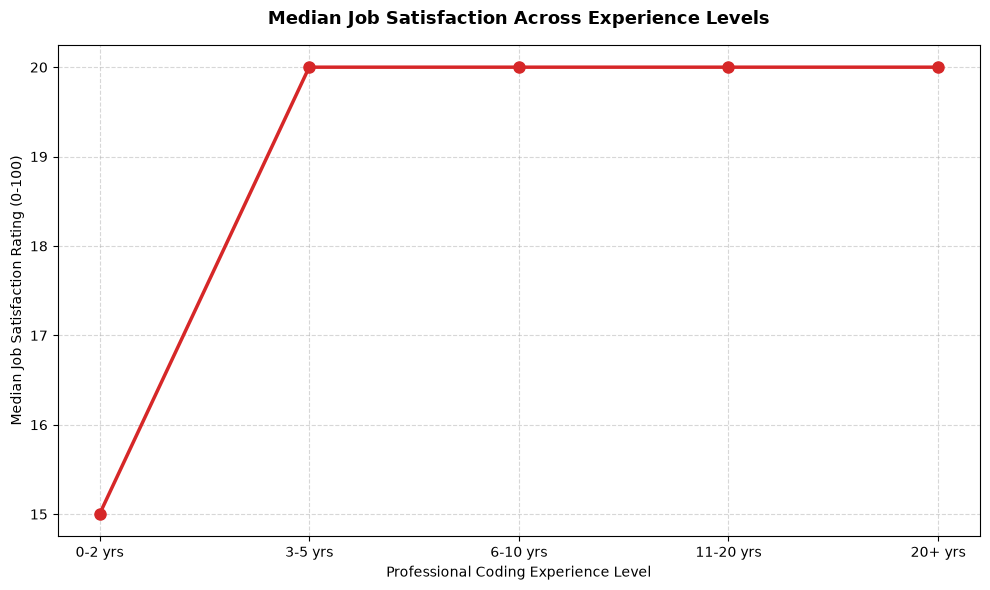

In [10]:
# Select YearsCodePro and JobSatPoints_6 from df
df_exp_sat_line = df[["YearsCodePro", "JobSatPoints_6"]].dropna().copy()

# Clean numeric values in YearsCodePro
df_exp_sat_line["YearsCodePro_Num"] = (
    df_exp_sat_line["YearsCodePro"]
    .str.replace("Less than 1 year", "0.5")
    .str.replace("More than 50 years", "51")
)
df_exp_sat_line["YearsCodePro_Num"] = pd.to_numeric(
    df_exp_sat_line["YearsCodePro_Num"], errors="coerce"
)

# Bin experience into clear ordinal levels
exp_bins = [-1, 2, 5, 10, 20, 100]
exp_labels = ["0-2 yrs", "3-5 yrs", "6-10 yrs", "11-20 yrs", "20+ yrs"]

df_exp_sat_line["Exp_Level"] = pd.cut(
    df_exp_sat_line["YearsCodePro_Num"],
    bins=exp_bins,
    labels=exp_labels,
)

# Drop missing values
df_exp_sat_line = df_exp_sat_line.dropna(
    subset=["Exp_Level", "JobSatPoints_6"]
).copy()

# Calculate median job satisfaction per experience level
median_sat_exp = (
    df_exp_sat_line.groupby("Exp_Level")["JobSatPoints_6"]
    .median()
    .reindex(exp_labels)
    .reset_index()
)

# Render Line Chart
plt.figure(figsize=(10, 6))

plt.plot(
    median_sat_exp["Exp_Level"],
    median_sat_exp["JobSatPoints_6"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#d62728",
)

plt.title(
    "Median Job Satisfaction Across Experience Levels",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Professional Coding Experience Level", fontsize=10)
plt.ylabel("Median Job Satisfaction Rating (0-100)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Initial Early-Career Climb (0–3 Years): Job satisfaction starts at its lowest point for entry-level developers (0–2 years) and rises steadily up to around the 3-year mark as engineers gain footing, confidence, and basic workplace autonomy.

Plateau at a Low Baseline: After 3 years of experience, job satisfaction completely plateaus and remains flat across all subsequent experience tiers (3–5 years, 6–10 years, 11–20 years, and 20+ years).

Low Overall Satisfaction Ceiling: Even with the early rise, the median rating remains at a surprisingly low baseline overall—reconfirming that accumulating years of professional coding experience alone does not automatically resolve workplace frustration or elevate job contentment.

### Task 3: Trends in Job Satisfaction and Compensation by Experience


##### 1.Line Chart of Median ConvertedCompYearly Over Experience Level

- This line chart will track how median compensation (`ConvertedCompYearly`) changes with increasing experience.

- Use a column such as `WorkExp` or another relevant experience-related column.


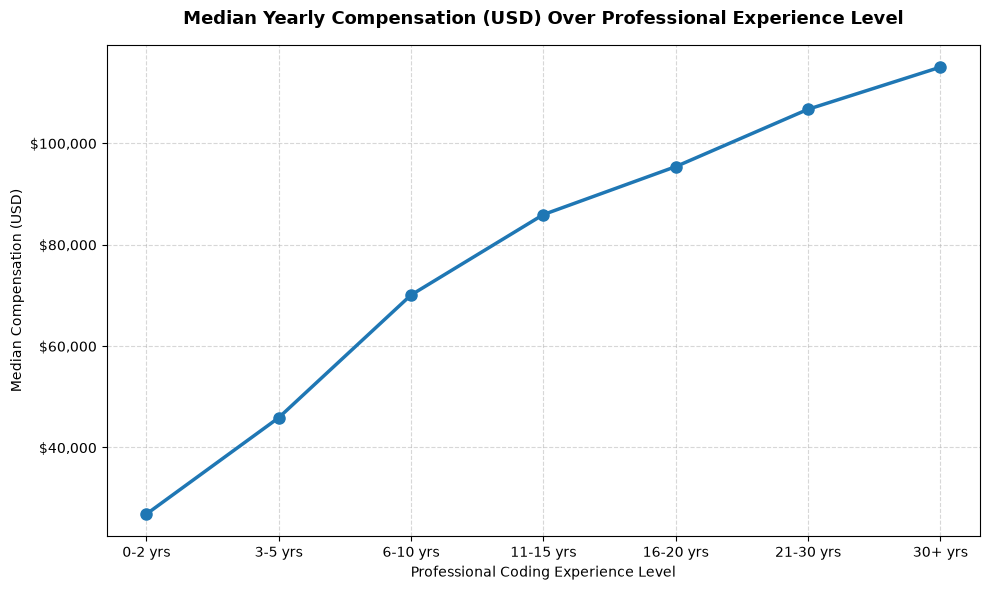

In [11]:
## Write your code here
# Select YearsCodePro and ConvertedCompYearly from df
cols = ["YearsCodePro", "ConvertedCompYearly"]
df_exp_comp = df[cols].dropna().copy()

# Filter out non-positive compensation values
df_exp_comp = df_exp_comp[df_exp_comp["ConvertedCompYearly"] > 0].copy()

# Clean numeric values in YearsCodePro
df_exp_comp["YearsCodePro_Num"] = (
    df_exp_comp["YearsCodePro"]
    .str.replace("Less than 1 year", "0.5")
    .str.replace("More than 50 years", "51")
)
df_exp_comp["YearsCodePro_Num"] = pd.to_numeric(
    df_exp_comp["YearsCodePro_Num"], errors="coerce"
)

# Bin professional experience into clear ordinal levels
exp_bins = [-1, 2, 5, 10, 15, 20, 30, 100]
exp_labels = [
    "0-2 yrs",
    "3-5 yrs",
    "6-10 yrs",
    "11-15 yrs",
    "16-20 yrs",
    "21-30 yrs",
    "30+ yrs",
]

df_exp_comp["Exp_Level"] = pd.cut(
    df_exp_comp["YearsCodePro_Num"],
    bins=exp_bins,
    labels=exp_labels,
)

# Drop missing values
df_exp_comp = df_exp_comp.dropna(
    subset=["Exp_Level", "ConvertedCompYearly"]
).copy()

# Calculate median yearly compensation per experience level
median_comp_exp = (
    df_exp_comp.groupby("Exp_Level")["ConvertedCompYearly"]
    .median()
    .reindex(exp_labels)
    .reset_index()
)

# Render Line Chart
plt.figure(figsize=(10, 6))

plt.plot(
    median_comp_exp["Exp_Level"],
    median_comp_exp["ConvertedCompYearly"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#1f77b4",
)

plt.title(
    "Median Yearly Compensation (USD) Over Professional Experience Level",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Professional Coding Experience Level", fontsize=10)
plt.ylabel("Median Compensation (USD)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

# Format y-axis values as currency
plt.gca().yaxis.set_major_formatter("${x:,.0f}")

plt.tight_layout()
plt.show()

Median yearly compensation demonstrates a strong, continuous upward trend as professional coding experience increases. Across the career span, median compensation multiplies over 5 times from entry-level (0–2 years) to veteran tiers (20+ years). This highlights that while job satisfaction remains flat across experience levels, financial growth continues steadily throughout a developer's career.

##### 2.Line Chart of Job Satisfaction (`JobSatPoints_6`) Across Experience Levels

- Create a line chart to explore trends in job satisfaction (`JobSatPoints_6`) based on experience level.

- This chart will provide insight into how satisfaction correlates with experience over time


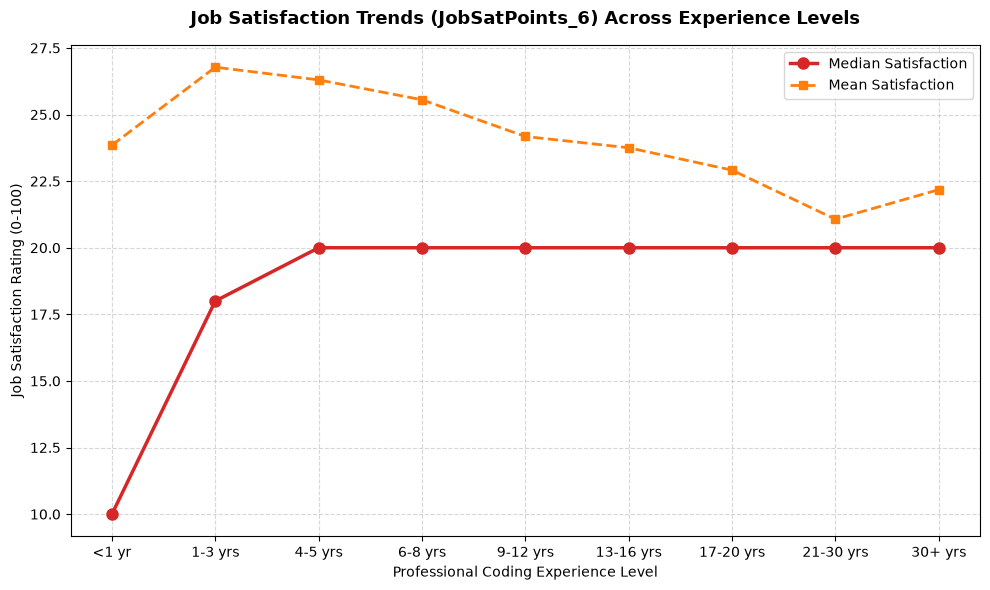

In [12]:
## Write your code here
# Select YearsCodePro and JobSatPoints_6 from df
df_exp_sat_trend = df[["YearsCodePro", "JobSatPoints_6"]].dropna().copy()

# Clean numeric values in YearsCodePro
df_exp_sat_trend["YearsCodePro_Num"] = (
    df_exp_sat_trend["YearsCodePro"]
    .str.replace("Less than 1 year", "0.5")
    .str.replace("More than 50 years", "51")
)
df_exp_sat_trend["YearsCodePro_Num"] = pd.to_numeric(
    df_exp_sat_trend["YearsCodePro_Num"], errors="coerce"
)

# Bin experience into granular experience levels
exp_bins = [-1, 1, 3, 5, 8, 12, 16, 20, 30, 100]
exp_labels = [
    "<1 yr",
    "1-3 yrs",
    "4-5 yrs",
    "6-8 yrs",
    "9-12 yrs",
    "13-16 yrs",
    "17-20 yrs",
    "21-30 yrs",
    "30+ yrs",
]

df_exp_sat_trend["Exp_Level"] = pd.cut(
    df_exp_sat_trend["YearsCodePro_Num"],
    bins=exp_bins,
    labels=exp_labels,
)

# Drop missing values
df_exp_sat_trend = df_exp_sat_trend.dropna(
    subset=["Exp_Level", "JobSatPoints_6"]
).copy()

# Calculate mean and median job satisfaction per experience level
sat_trend_summary = (
    df_exp_sat_trend.groupby("Exp_Level")["JobSatPoints_6"]
    .agg(["median", "mean"])
    .reindex(exp_labels)
    .reset_index()
)

# Render Line Chart
plt.figure(figsize=(10, 6))

plt.plot(
    sat_trend_summary["Exp_Level"],
    sat_trend_summary["median"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#d62728",
    label="Median Satisfaction",
)

plt.plot(
    sat_trend_summary["Exp_Level"],
    sat_trend_summary["mean"],
    marker="s",
    linewidth=2,
    markersize=6,
    color="#ff7f0e",
    linestyle="--",
    label="Mean Satisfaction",
)

plt.title(
    "Job Satisfaction Trends (JobSatPoints_6) Across Experience Levels",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Professional Coding Experience Level", fontsize=10)
plt.ylabel("Job Satisfaction Rating (0-100)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="best", frameon=True)

plt.tight_layout()
plt.show()

Median Trajectory: Median job satisfaction doubles from 10 (<1 year) to 20 (4–5 years) during the early-career onboarding period, but then completely plateaus at 20 across all remaining experience brackets (5 to 30+ years).

Mean Trajectory: Mean satisfaction peaks early at 27 (1–3 years) before steadily declining to 21 (21–30 years), followed by a minor uptick to 22 at 30+ years.

Analytical Conclusion: While compensation multiplies over 5x across a developer's career, job satisfaction peaks early and stays low/flat long-term, proving that financial compounding does not guarantee higher job contentment over time.

#### Final Step: Review


In this lab, you focused on analyzing trends in compensation and job satisfaction, specifically exploring how these metrics change with age and experience levels using line charts.


### Summary


In this lab, you explored essential data visualization techniques with a focus on analyzing trends using line charts. You learned to:

- Visualize the distribution of compensation across age groups to understand salary trends.

- Track changes in median compensation over various experience levels, identifying how earnings progress with experience.

- Examine trends in job satisfaction by experience, revealing how satisfaction varies throughout a developer's career.

These analyses allow for a deeper understanding of how factors like age and experience influence job satisfaction and compensation. By using line charts, you gained insights into continuous data patterns, which are invaluable for interpreting professional trends in the developer community.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
